In [5]:
# Import relevant libraries

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from pycbc.waveform import get_td_waveform
from scipy.signal import spectrogram
from matplotlib.colors import LogNorm
from pycbc.filter import match
from tqdm.auto import tqdm

In [6]:
# Create helper function for waveform

def generate_waveform(
    mass,
    spin1z=0.9,
    spin2z=0.9,
    inclination=np.pi / 3,
    distance=1000,
    delta_t=10.0,
    f_lower=1.0e-4
):
    hp, hc = get_td_waveform(
        approximant='IMRPhenomXHM',
        mass1=mass,
        mass2=mass,
        spin1z=spin1z,
        spin2z=spin2z,
        inclination=inclination,
        delta_t=delta_t,
        f_lower=f_lower,
        distance=distance
    )
    hp = hp.trim_zeros()
    return hp

In [7]:
h1 = generate_waveform(
    mass=1e6,
    inclination=np.pi / 3,
    distance=1000
)

h2 = generate_waveform(
    mass=1e6,
    inclination=np.pi / 3,
    distance=2000
)

h3 = generate_waveform(
    mass=1e6,
    inclination=0.3,
    distance=1000
)

print(np.max(np.abs(np.array(h1))))
print(np.max(np.abs(np.array(h2))))
print(np.max(np.abs(np.array(h3))))

1.4875048057260353e-17
7.437524028630176e-18
2.478630175174973e-17


In [8]:
# Create time domain subplot helper

def plot_td_grid(param_values, param_name, fixed_params, figsize=(12, 8)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    for ax, value in zip(axes, param_values):
        params = fixed_params.copy()
        params[param_name] = value
        hp = generate_waveform(**params)
        t = hp.sample_times.numpy()
        h = hp.numpy()
        ax.plot(t, h, lw=1)
        ax.set_title(f"{param_name} = {value:.1e}")
        ax.set_xlim(-5.0e7, 0)
        ax.set_ylim(-4.0e-14, 4.0e-14)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Strain")
    plt.tight_layout()
    return fig

In [9]:
# Create zoomed time domain subplot helper

def plot_zoomed_td_grid(param_values, param_name, fixed_params, zoom_secs=1.0e6, figsize=(12, 8)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    for ax, value in zip(axes, param_values):
        params = fixed_params.copy()
        params[param_name] = value
        hp = generate_waveform(**params)
        t = hp.sample_times.numpy()
        h = hp.numpy()
        mask = t > (t.max() - zoom_secs)
        ax.plot(t[mask], h[mask], lw=1)
        ax.set_title(f'{param_name} = {value:.1e}')
        ax.set_ylim(-4.0e-14, 4.0e-14)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Strain')
    plt.tight_layout()
    return fig

In [10]:
# Create frequency domain subplot helper

def plot_fd_grid(param_values, param_name, fixed_params, figsize=(12, 8)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    for ax, value in zip(axes, param_values):
        params = fixed_params.copy()
        params[param_name] = value
        hp = generate_waveform(**params)
        hf = hp.to_frequencyseries()
        f = hf.sample_frequencies.numpy()
        amp = np.abs(hf.numpy())
        mask = (f > 1.0e-5) & (f < 1.0e-1)
        ax.loglog(f[mask], amp[mask], lw=1)
        ax.set_title(f'{param_name} = {value:.1e}')
        ax.set_ylim(1.0e-28, 1.0e-9)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('abs(h(f))')
    plt.tight_layout()
    return fig

In [11]:
# Create spectrogram subplot helper

def plot_spectrogram_grid(param_values, param_name, fixed_params, segment_length=1.0e7, nperseg=16384, noverlap=12288, figsize=(12, 8)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    for ax, value in zip(axes, param_values):
        params = fixed_params.copy()
        params[param_name] = value
        hp = generate_waveform(**params)
        t = hp.sample_times.numpy()
        h = hp.numpy()
        mask = t > (t.max() - segment_length)
        t_zoom = t[mask]
        h_zoom = h[mask]
        fs = 1.0 / params['delta_t']
        f, tt, Sxx = spectrogram(
            h_zoom,
            fs=fs,
            nperseg=nperseg,
            noverlap=noverlap,
            scaling='density',
            mode='magnitude'
        )
        positive = Sxx[Sxx > 0]
        vmin = positive.min() if len(positive) > 0 else 1.0e-30
        pcm = ax.pcolormesh(
            tt + t_zoom.min(),
            f,
            Sxx,
            shading='gouraud',
            norm=LogNorm(vmin=vmin, vmax=Sxx.max())
        )
        ax.set_yscale('log')
        ax.set_ylim(1.0e-4, 1.0e-2)
        ax.set_title(f'{param_name} = {value:.1e}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Frequency (Hz)')
    plt.tight_layout()
    return fig

In [12]:
def waveform_match(h1, h2, f_low=1.0e-4):
    # match() requires compatible lengths
    n = max(len(h1), len(h2))

    h1 = h1.copy()
    h2 = h2.copy()

    h1.resize(n)
    h2.resize(n)

    m, _ = match(
        h1,
        h2,
        low_frequency_cutoff=f_low,
        subsample_interpolation=True
    )

    return float(m)

In [13]:
def waveform_difference(h_ref, h):
    n = max(len(h_ref), len(h))

    a = h_ref.copy()
    b = h.copy()

    a.resize(n)
    b.resize(n)

    return np.sqrt(
        np.sum((a.numpy() - b.numpy())**2)
        / np.sum(a.numpy()**2)
    )

In [14]:
reference_params = {
    "mass": 1e6,
    "spin1z": 0.9,
    "spin2z": 0.9,
    "inclination": np.pi / 3,
    "distance": 1000,
    "delta_t": 10.0,
    "f_lower": 1e-4
}

h_ref = generate_waveform(**reference_params)

In [29]:
distance_values = np.linspace(750, 1600, 21)
inclination_values = np.linspace(0.45, 1.4, 21)

difference_grid = np.zeros(
    (len(inclination_values), len(distance_values))
)

In [30]:
total = len(inclination_values) * len(distance_values)

with tqdm(total=total, desc="Computing waveforms") as pbar:
    for i, inc in enumerate(inclination_values):
        for j, dist in enumerate(distance_values):

            h = generate_waveform(
                mass=1e6,
                spin1z=0.9,
                spin2z=0.9,
                inclination=inc,
                distance=dist,
                delta_t=10.0,
                f_lower=1e-4
            )

            difference_grid[i, j] = waveform_difference(
                h_ref, h
            )

            pbar.update(1)

Computing waveforms:   0%|          | 0/441 [00:00<?, ?it/s]

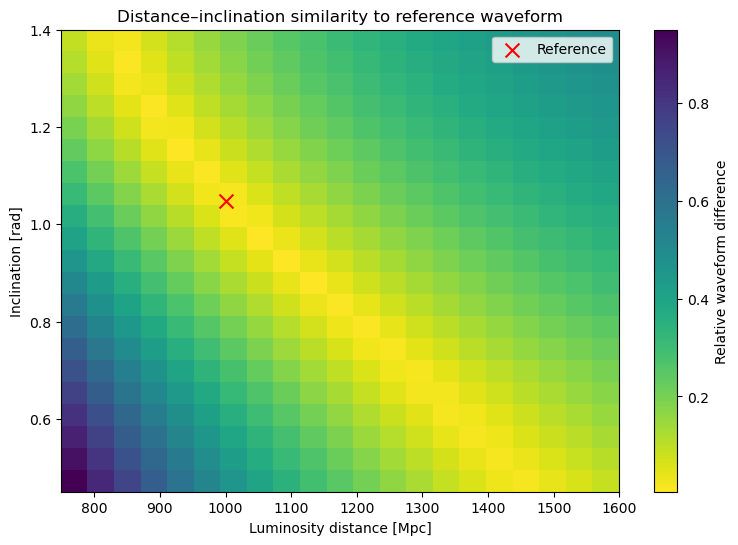

In [31]:
plt.figure(figsize=(9, 6))

im = plt.imshow(
    difference_grid,
    origin="lower",
    aspect="auto",
    extent=[
        distance_values[0],
        distance_values[-1],
        inclination_values[0],
        inclination_values[-1]
    ],
    cmap="viridis_r"
)

plt.colorbar(im, label="Relative waveform difference")

plt.scatter(
    reference_params["distance"],
    reference_params["inclination"],
    marker="x",
    s=100,
    color="red",
    label="Reference"
)

plt.xlabel("Luminosity distance [Mpc]")
plt.ylabel("Inclination [rad]")
plt.title("Distance–inclination similarity to reference waveform")
plt.legend()

plt.show()

In [32]:
print(
    "Difference range:",
    difference_grid.min(),
    difference_grid.max()
)

Difference range: 0.005040587153413005 0.9504884916799453


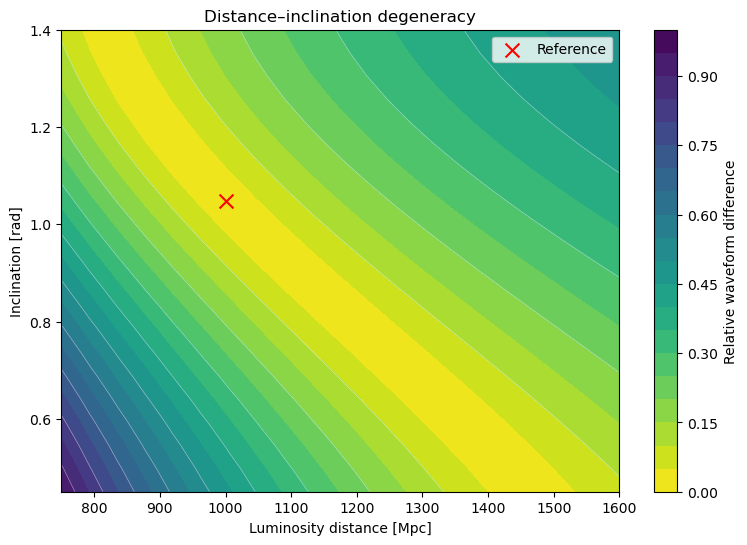

In [33]:
D, I = np.meshgrid(
    distance_values,
    inclination_values
)

plt.figure(figsize=(9, 6))

cf = plt.contourf(
    D,
    I,
    difference_grid,
    levels=20,
    cmap="viridis_r"
)

plt.colorbar(cf, label="Relative waveform difference")

plt.contour(
    D,
    I,
    difference_grid,
    levels=10,
    colors="white",
    linewidths=0.5,
    alpha=0.5
)

plt.scatter(
    reference_params["distance"],
    reference_params["inclination"],
    marker="x",
    s=100,
    color="red",
    label="Reference"
)

plt.xlabel("Luminosity distance [Mpc]")
plt.ylabel("Inclination [rad]")
plt.title("Distance–inclination degeneracy")
plt.legend()

plt.show()

In [34]:
def nearest_grid_point(target_distance, target_inclination,
                       distance_values, inclination_values, difference_grid):
    j = np.argmin(np.abs(distance_values - target_distance))
    i = np.argmin(np.abs(inclination_values - target_inclination))

    return {
        "distance": distance_values[j],
        "inclination": inclination_values[i],
        "difference": difference_grid[i, j],
        "i": i,
        "j": j
    }

In [35]:
candidate_targets = [
    (1000, 1.05),  # reference neighbourhood
    (800, 1.40),   # nearer + more inclined
    (1500, 0.55),  # farther + less inclined
]

selected_points = [
    nearest_grid_point(d, inc, distance_values, inclination_values, difference_grid)
    for d, inc in candidate_targets
]

for p in selected_points:
    print(
        f"D = {p['distance']:.1f} Mpc, "
        f"iota = {p['inclination']:.3f} rad, "
        f"difference = {p['difference']:.4f}"
    )

D = 1005.0 Mpc, iota = 1.068 rad, difference = 0.0192
D = 792.5 Mpc, iota = 1.400 rad, difference = 0.0338
D = 1515.0 Mpc, iota = 0.545 rad, difference = 0.0794


/var/folders/4p/rtytcsp11j70tn7dmwys7lrm0000gn/T/ipykernel_13016/1218131134.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


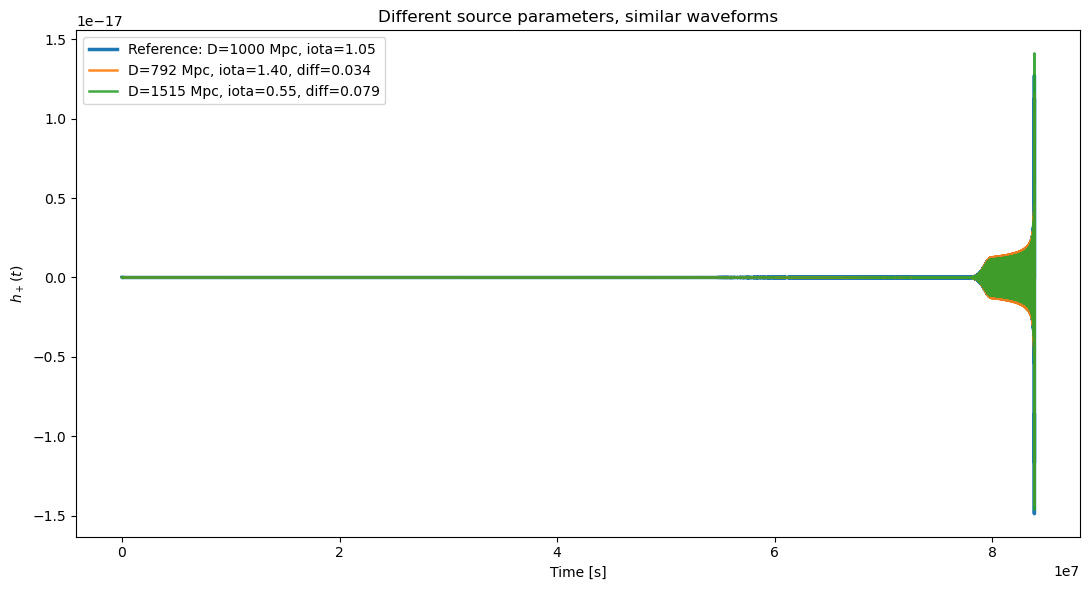

In [36]:
plt.figure(figsize=(11, 6))

# Reference waveform
h_ref = generate_waveform(**reference_params)

t_ref = np.arange(len(h_ref)) * h_ref.delta_t
plt.plot(
    t_ref,
    h_ref.numpy(),
    linewidth=2.5,
    label=(
        f"Reference: D={reference_params['distance']:.0f} Mpc, "
        f"iota={reference_params['inclination']:.2f}"
    )
)

# Candidate waveforms
for p in selected_points[1:]:
    h = generate_waveform(
        mass=reference_params["mass"],
        spin1z=reference_params["spin1z"],
        spin2z=reference_params["spin2z"],
        inclination=p["inclination"],
        distance=p["distance"],
        delta_t=reference_params["delta_t"],
        f_lower=reference_params["f_lower"]
    )

    t = np.arange(len(h)) * h.delta_t

    plt.plot(
        t,
        h.numpy(),
        linewidth=1.8,
        alpha=0.9,
        label=(
            f"D={p['distance']:.0f} Mpc, "
            f"iota={p['inclination']:.2f}, "
            f"diff={p['difference']:.3f}"
        )
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$h_+(t)$")
plt.title("Different source parameters, similar waveforms")
plt.legend()
plt.tight_layout()
plt.show()

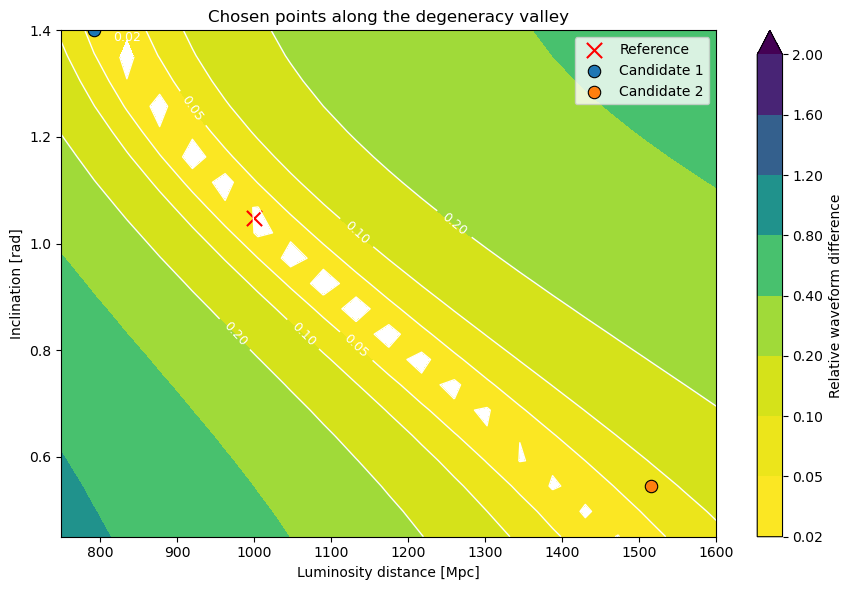

In [37]:
plt.figure(figsize=(9, 6))
levels = [0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0]
cf = plt.contourf(
    D,
    I,
    difference_grid,
    levels=levels,
    cmap="viridis_r",
    extend="max"
)

plt.colorbar(cf, label="Relative waveform difference")

cs = plt.contour(
    D,
    I,
    difference_grid,
    levels=[0.02, 0.05, 0.1, 0.2],
    colors="white",
    linewidths=1.0
)

plt.clabel(cs, fmt="%.02f", fontsize=9)

plt.scatter(
    reference_params["distance"],
    reference_params["inclination"],
    marker="x",
    s=120,
    color="red",
    label="Reference"
)

for k, p in enumerate(selected_points[1:], start=1):
    plt.scatter(
        p["distance"],
        p["inclination"],
        s=80,
        edgecolor="black",
        linewidth=0.8,
        label=f"Candidate {k}"
    )

plt.xlabel("Luminosity distance [Mpc]")
plt.ylabel("Inclination [rad]")
plt.title("Chosen points along the degeneracy valley")
plt.legend()
plt.tight_layout()
plt.show()

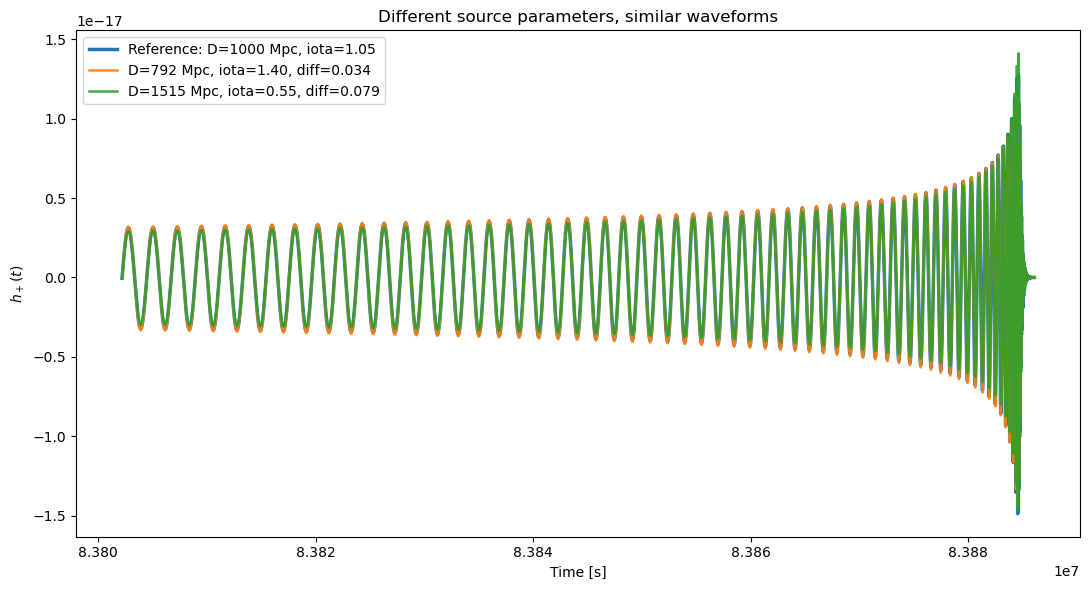

In [38]:
plt.figure(figsize=(11, 6))

h_ref = generate_waveform(**reference_params)

n_ref = len(h_ref)
start_ref = int(0.999 * n_ref)

t_ref = np.arange(n_ref) * h_ref.delta_t

plt.plot(
    t_ref[start_ref:],
    h_ref.numpy()[start_ref:],
    linewidth=2.5,
    label=(
        f"Reference: D={reference_params['distance']:.0f} Mpc, "
        f"iota={reference_params['inclination']:.2f}"
    )
)

for p in selected_points[1:]:
    h = generate_waveform(
        mass=reference_params["mass"],
        spin1z=reference_params["spin1z"],
        spin2z=reference_params["spin2z"],
        inclination=p["inclination"],
        distance=p["distance"],
        delta_t=reference_params["delta_t"],
        f_lower=reference_params["f_lower"]
    )

    n = len(h)
    start = int(0.999 * n)
    t = np.arange(n) * h.delta_t

    plt.plot(
        t[start:],
        h.numpy()[start:],
        linewidth=1.8,
        alpha=0.9,
        label=(
            f"D={p['distance']:.0f} Mpc, "
            f"iota={p['inclination']:.2f}, "
            f"diff={p['difference']:.3f}"
        )
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$h_+(t)$")
plt.title("Different source parameters, similar waveforms")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
candidates = []

for i, inc in enumerate(inclination_values):
    for j, dist in enumerate(distance_values):
        diff = difference_grid[i, j]

        if diff < 0.05:
            candidates.append({
                "distance": dist,
                "inclination": inc,
                "difference": diff
            })

sorted(
    candidates,
    key=lambda x: x["difference"]
)[:10]

[{'distance': 1090.0,
  'inclination': 0.925,
  'difference': 0.005040587153413005},
 {'distance': 920.0,
  'inclination': 1.1625,
  'difference': 0.005952141723437558},
 {'distance': 1132.5,
  'inclination': 0.8775,
  'difference': 0.006346676434555272},
 {'distance': 1047.5,
  'inclination': 0.9724999999999999,
  'difference': 0.008072357287320881},
 {'distance': 1175.0,
  'inclination': 0.8300000000000001,
  'difference': 0.009062671052939035},
 {'distance': 962.5, 'inclination': 1.115, 'difference': 0.009553377155203309},
 {'distance': 877.5,
  'inclination': 1.2575,
  'difference': 0.009575402483975018},
 {'distance': 835.0,
  'inclination': 1.3525,
  'difference': 0.010555768955150707},
 {'distance': 1217.5,
  'inclination': 0.7825,
  'difference': 0.011813174728634036},
 {'distance': 1260.0,
  'inclination': 0.7350000000000001,
  'difference': 0.014507216099478663}]

In [40]:
ref_D = reference_params["distance"]
ref_i = reference_params["inclination"]

good_points = []

for i, inc in enumerate(inclination_values):
    for j, dist in enumerate(distance_values):
        diff = difference_grid[i, j]

        if diff < 0.02:
            separation = np.sqrt(
                ((dist - ref_D) / ref_D)**2
                + ((inc - ref_i) / ref_i)**2
            )

            good_points.append({
                "distance": dist,
                "inclination": inc,
                "difference": diff,
                "separation": separation
            })

sorted(
    good_points,
    key=lambda x: x["separation"],
    reverse=True
)[:10]

[{'distance': 1472.5,
  'inclination': 0.45,
  'difference': 0.019093039590833315,
  'separation': 0.740592610341155},
 {'distance': 1430.0,
  'inclination': 0.4975,
  'difference': 0.016975563613878565,
  'separation': 0.6785599646466567},
 {'distance': 1387.5,
  'inclination': 0.545,
  'difference': 0.01734978698823767,
  'separation': 0.6165527092806363},
 {'distance': 1345.0,
  'inclination': 0.5925,
  'difference': 0.019207990390253796,
  'separation': 0.5545793609502503},
 {'distance': 1302.5,
  'inclination': 0.6875,
  'difference': 0.017282908813835228,
  'separation': 0.45769944925180084},
 {'distance': 1260.0,
  'inclination': 0.7350000000000001,
  'difference': 0.014507216099478663,
  'separation': 0.39557493579361214},
 {'distance': 835.0,
  'inclination': 1.3525,
  'difference': 0.010555768955150707,
  'separation': 0.3349954470359799},
 {'distance': 1217.5,
  'inclination': 0.7825,
  'difference': 0.011813174728634036,
  'separation': 0.33346316195573},
 {'distance': 1175

In [45]:
comparison_points = [
    {
        "label": "On valley",
        "distance": 1472.5,
        "inclination": 0.45
    },
    {
        "label": "Off valley",
        "distance": 1472.5,
        "inclination": 1.05
    }
]

In [43]:
import json

grid_data = {
    "distances": distance_values.tolist(),
    "inclinations": inclination_values.tolist(),
    "difference": difference_grid.tolist(),
    "reference": {
        "distance": reference_params["distance"],
        "inclination": reference_params["inclination"]
    }
}

with open("data/degeneracy-grid.json", "w") as f:
    json.dump(grid_data, f)

In [44]:
def prepare_for_web(h, fraction=0.02, n_points=1500):
    y = h.numpy()

    start = int((1 - fraction) * len(y))
    y = y[start:]

    idx = np.linspace(
        0,
        len(y) - 1,
        min(n_points, len(y))
    ).astype(int)

    y = y[idx]

    # Time relative to the beginning of displayed segment
    t = np.arange(len(y)) * h.delta_t

    return t.tolist(), y.tolist()

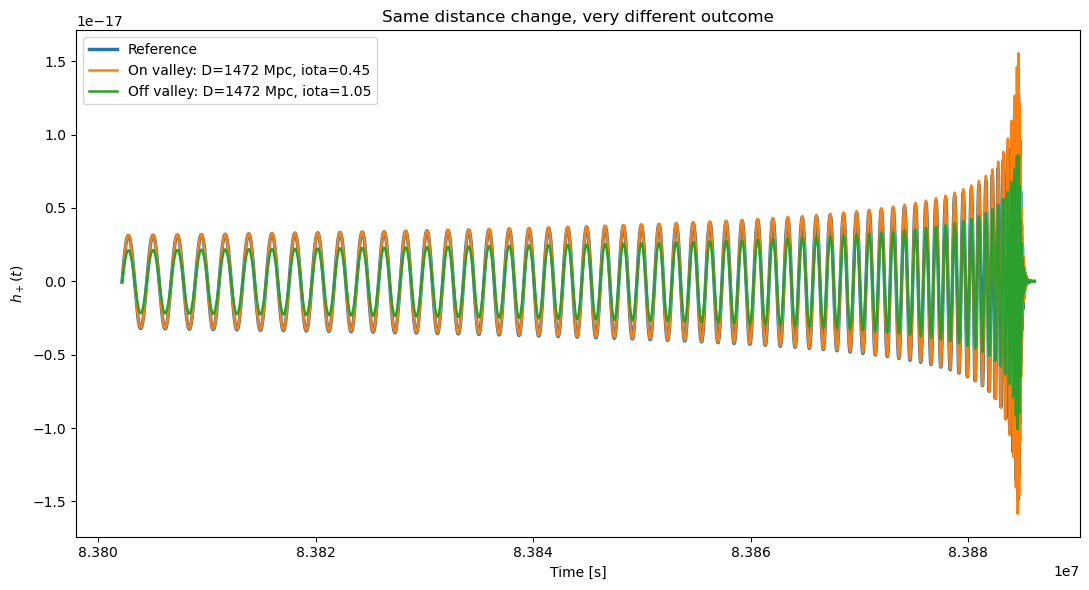

In [46]:
plt.figure(figsize=(11, 6))

h_ref = generate_waveform(**reference_params)

start_ref = int(0.999 * len(h_ref))
t_ref = np.arange(len(h_ref)) * h_ref.delta_t

plt.plot(
    t_ref[start_ref:],
    h_ref.numpy()[start_ref:],
    linewidth=2.5,
    label="Reference"
)

for p in comparison_points:
    h = generate_waveform(
        mass=reference_params["mass"],
        spin1z=reference_params["spin1z"],
        spin2z=reference_params["spin2z"],
        inclination=p["inclination"],
        distance=p["distance"],
        delta_t=reference_params["delta_t"],
        f_lower=reference_params["f_lower"]
    )

    start = int(0.999 * len(h))
    t = np.arange(len(h)) * h.delta_t

    plt.plot(
        t[start:],
        h.numpy()[start:],
        linewidth=1.8,
        label=(
            f"{p['label']}: "
            f"D={p['distance']:.0f} Mpc, "
            f"iota={p['inclination']:.2f}"
        )
    )

plt.xlabel("Time [s]")
plt.ylabel(r"$h_+(t)$")
plt.title("Same distance change, very different outcome")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
from pathlib import Path

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

In [49]:
import json

grid_data = {
    "distances": distance_values.tolist(),
    "inclinations": inclination_values.tolist(),
    "difference": difference_grid.tolist(),
    "reference": {
        "distance": float(reference_params["distance"]),
        "inclination": float(reference_params["inclination"]),
        "mass": float(reference_params["mass"]),
        "spin1z": float(reference_params["spin1z"]),
        "spin2z": float(reference_params["spin2z"]),
        "delta_t": float(reference_params["delta_t"]),
        "f_lower": float(reference_params["f_lower"])
    }
}

with open(data_dir / "degeneracy-grid.json", "w") as f:
    json.dump(grid_data, f, indent=2)

In [50]:
import numpy as np

def prepare_for_web(h, fraction=0.02, n_points=1500):
    y = h.numpy()

    start = int((1 - fraction) * len(y))
    y = y[start:]

    idx = np.linspace(
        0,
        len(y) - 1,
        min(n_points, len(y))
    ).astype(int)

    y = y[idx]

    t = idx * h.delta_t
    t = t - t[0]

    return t.tolist(), y.tolist()

In [51]:
waveform_points = [
    {"label": "Reference", "distance": 1000.0, "inclination": 1.05},

    {"label": "Valley A", "distance": 835.0, "inclination": 1.3525},
    {"label": "Valley B", "distance": 1260.0, "inclination": 0.7350},
    {"label": "Valley C", "distance": 1472.5, "inclination": 0.45},

    {"label": "Off-valley A", "distance": 1472.5, "inclination": 1.05},
    {"label": "Off-valley B", "distance": 835.0, "inclination": 0.80},
]

In [54]:
waveform_bank = []

for p in waveform_points:
    h = generate_waveform(
        mass=reference_params["mass"],
        spin1z=reference_params["spin1z"],
        spin2z=reference_params["spin2z"],
        inclination=p["inclination"],
        distance=p["distance"],
        delta_t=reference_params["delta_t"],
        f_lower=reference_params["f_lower"]
    )

    t, y = prepare_for_web(h, fraction=0.0001, n_points=1500)

    waveform_bank.append({
        "label": p["label"],
        "distance": float(p["distance"]),
        "inclination": float(p["inclination"]),
        "time": t,
        "strain": y
    })

with open(data_dir / "waveform-bank.json", "w") as f:
    json.dump(waveform_bank, f, indent=2)

In [53]:
best_points = [
    {
        "distance": float(p["distance"]),
        "inclination": float(p["inclination"]),
        "difference": float(p["difference"]),
        "separation": float(p["separation"])
    }
    for p in good_points
]

with open(data_dir / "similar-points.json", "w") as f:
    json.dump(best_points, f, indent=2)